In this notebook, we have a dataset of user comments for youtube videos related to animals or pets. We will attempt to identify cat or dog owners based on these comments, find out the topics important to them, and then identify video creators with the most viewers that are cat or dog owners.


### Project Summary   
**  Overview **: This project aims to build up classification models for the cat and dog owners from text comments. There are around 6,000,000 comments recorded in the dataset and the dataset itself is unlabeled. Each data row will have an userid, an text comment and belongs to one channel. 

** Details ** : 
1. Searched specific terms which a cat/dog owner might have, and label those users as dog&cat owners.  Also labeled users who don't have pets as those whose comments don't contain any specific terms.  By this way, we turn our dataset into labeled ones and convert problem from unsupervised to supervised.   
2. Use RegexTokenizer to tokenize text comments.
       * RegexTokenizer allows more advanced tokenization based on regular expression (regex) matching. By default, the parameter “pattern” is used as delimiters to split the input text. Alternatively, users can set parameter “gaps” to false indicating the regex “pattern” denotes “tokens” rather than splitting gaps, and find all matching occurrences as the tokenization result.  
3. Use Word2Vec represent text features as vectors. 
4. Train Logistic regression model and random forest model to classify audiences. Evaluation metrics are include: precision, recall, accuracy, AUC. Based on my analysis (I only randomly pick a small portion of dataset for training in order to speed process up)  random forest outperforms LR model.
5. Use our trained model to predict all users in the dataset. And get statistical sense of how dog&cat owners' distribution.  Extract word frequency to see related topics regards to those owner.



#### 0. Data Exploration and Cleaning


In [2]:
# ============================================================
# Local PySpark setup  (replaces the Databricks-managed `spark`)
# ============================================================
# Requirements (install once):  pip install pyspark wordcloud matplotlib
# plus a working Java 8/11/17 (JAVA_HOME set).  Launch Jupyter from this project folder.
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("YoutubeCommentsOwnerClassifier")
         .master("local[*]")                       # use all CPU cores
         .config("spark.driver.memory", "8g")      # you have 16GB+, can raise to 10-12g
         .config("spark.sql.shuffle.partitions", "16")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

# Path to the local data file (relative to this notebook's folder).
# Make it an absolute path if you launch Jupyter from a different directory.
DATA_PATH = "animals_comments/animals_comments.csv"
print("Spark", spark.version, "ready")

Spark 4.1.2 ready


In [3]:
# read data (local file)
df = (spark.read
        .option("header", True)
        .option("inferSchema", True)
        .option("multiLine", True)     # comments can span multiple lines / contain quotes
        .option("quote", '"')
        .option("escape", '"')
        .csv(DATA_PATH))

# multiLine reads the file as a single partition; repartition to restore parallelism
df = df.repartition(8)
df.show(10)

+------------------+---------+--------------------+
|      creator_name|   userid|             comment|
+------------------+---------+--------------------+
|     eMusic Talent|2014418.0|Unlike fifth harm...|
|The Pet Collective| 835123.0|this is so doggon...|
|  Brave Wilderness| 662418.0|I found some yest...|
| Talking Kitty Cat|2541561.0|           HAHAHAHAH|
|Taylor Nicole Dean|2485705.0|I just cried for ...|
|    Top View Viral| 154392.0|Like si quieres e...|
|      Robin Seplut|1247207.0|OMG! I want them ...|
|              NULL|  94765.0|What song is used...|
|  Cole & Marmalade|2487414.0|BIGCATRESCUE JSND...|
|    Dogumentary TV|1624776.0|  Link to her shirt?|
+------------------+---------+--------------------+
only showing top 10 rows


In [4]:
#check columns's datatype 
df.dtypes

[('creator_name', 'string'), ('userid', 'double'), ('comment', 'string')]

In [5]:
print("Number of rows in df:", df.count())

Number of rows in df: 5819470


In [6]:
# Count null values in each columns 
print('Number of null values in creator_name: ',df.filter(df['creator_name'].isNull()).count())
print('Number of null values in userid: ',df.filter(df['userid'].isNull()).count())
print('Number of null values in comment: ',df.filter(df['comment'].isNull()).count())

Number of null values in creator_name:  32050
Number of null values in userid:  0
Number of null values in comment:  486


In [7]:
#drop out rows with no comments and no userid
def pre_process(df):
  df_drop = df.filter(df['comment'].isNotNull())
  df_drop = df_drop.filter(df_drop['userid'].isNotNull())
  df_drop = df_drop.dropDuplicates()
  
  print('After dropping, we have ', str(df_drop.count()), 'row in dataframe')
  return df_drop

df_drop = pre_process(df)

After dropping, we have  5757213 row in dataframe


In [8]:
import pyspark.sql.functions as F
#convert text in comment to lower case.
df_clean = df_drop.withColumn('comment', F.lower(F.col('comment')))

In [9]:
df_clean.show(10, truncate=80)

+-------------------+---------+--------------------------------------------------------------------------------+
|       creator_name|   userid|                                                                         comment|
+-------------------+---------+--------------------------------------------------------------------------------+
|      Brian Barczyk|1837978.0|omg your cray cray you are so good with snakes i love you im going to get a p...|
|Solid Gold Aquatics| 601711.0|                                             like the aquarium the music stinks.|
|   Brave Wilderness| 738688.0|                                                           1 guy 2 jars of honey|
|         stacyvlogs|1817170.0|                                   aww im sooooo sorry hope she gets better soon|
| Taylor Nicole Dean|1061484.0|this is the best thing ive heard everhe can you know do his fins what the act...|
|   Brave Wilderness|1009874.0|ive actually gotten bite you could say by a little box turtle it 

##### This is an unlabeled dataset and we want to train a clasifier to identify cat and dog owners. Thus first thing to do is to label each comment. 
1. Label comment when he/she has dogs or cats.   
2. label comment when he/she don't have a dog or cat.   
3.  Combine 1 and 2 as our training dataset, and rest of the dataset will be the data we predict.   
4. The strategy to tell if a user own or not own is just using key words (like I have a dog) to tell. Otherwise we can't have better ways and don't have labels.

In [10]:
# find user with preference of dog and cat
# note: please propose your own approach and rule to label data 
cond = (df_clean["comment"].like("%my dog%") | df_clean["comment"].like("%i have a dog%")\
        | df_clean["comment"].like("%my cat%") | df_clean["comment"].like("%i have a cat%") \
        | df_clean["comment"].like("%my dogs%") | df_clean["comment"].like("%my cats%")\
        | df_clean["comment"].like("%my cat%") | df_clean["comment"].like("%i have dogs%")\
        | df_clean["comment"].like("%i have cats%") | df_clean["comment"].like("%my puppy%")\
        | df_clean["comment"].like("%my kitten%") | df_clean["comment"].like("%i have a puppy%")\
        | df_clean["comment"].like("%i have puppies%"))

df_clean = df_clean.withColumn('dog_cat',  cond)

# find user do not have 
df_clean = df_clean.withColumn('no_pet', ~df_clean["comment"].like("%my%") & ~df_clean["comment"].like("%have%") & ~df_clean["comment"].like("%my dog%") \
                              & ~df_clean["comment"].like("%my cat%")) 


In [11]:
df_clean.show(10)

+-------------------+---------+--------------------+-------+------+
|       creator_name|   userid|             comment|dog_cat|no_pet|
+-------------------+---------+--------------------+-------+------+
|      Brian Barczyk|1837978.0|omg your cray cra...|  false|  true|
|Solid Gold Aquatics| 601711.0|like the aquarium...|  false|  true|
|   Brave Wilderness| 738688.0|1 guy 2 jars of h...|  false|  true|
|         stacyvlogs|1817170.0|aww im sooooo sor...|  false|  true|
| Taylor Nicole Dean|1061484.0|this is the best ...|  false|  true|
|   Brave Wilderness|1009874.0|ive actually gott...|  false|  true|
|           The Dodo|1906164.0|awe i love rica! ...|  false|  true|
|           ViralHog| 428309.0|reading some of t...|  false| false|
| Taylor Nicole Dean| 342684.0|      we want cheese|  false|  true|
|       AlyssaNGames| 143748.0|         love it!!!!|  false|  true|
+-------------------+---------+--------------------+-------+------+
only showing top 10 rows


#### 1. Build the classifier 
In order to train a model against the comments, you can use RegexTokenizer to split each comment into a list of words and then use Word2Vec or other model to convert the list to a word vector. What Word2Vec does is to map each word to a unique fixed-size vector and then transform each document into a vector using the average of all words in the document.


In [12]:
# data preprocessing 
from pyspark.ml.feature import RegexTokenizer

regexTokenizer = RegexTokenizer(inputCol="comment", outputCol="text", pattern="\\W")
df_clean = regexTokenizer.transform(df_clean)
df_clean.show(10)

+-------------------+---------+--------------------+-------+------+--------------------+
|       creator_name|   userid|             comment|dog_cat|no_pet|                text|
+-------------------+---------+--------------------+-------+------+--------------------+
|      Brian Barczyk|1837978.0|omg your cray cra...|  false|  true|[omg, your, cray,...|
|Solid Gold Aquatics| 601711.0|like the aquarium...|  false|  true|[like, the, aquar...|
|   Brave Wilderness| 738688.0|1 guy 2 jars of h...|  false|  true|[1, guy, 2, jars,...|
|         stacyvlogs|1817170.0|aww im sooooo sor...|  false|  true|[aww, im, sooooo,...|
| Taylor Nicole Dean|1061484.0|this is the best ...|  false|  true|[this, is, the, b...|
|   Brave Wilderness|1009874.0|ive actually gott...|  false|  true|[ive, actually, g...|
|           The Dodo|1906164.0|awe i love rica! ...|  false|  true|[awe, i, love, ri...|
|           ViralHog| 428309.0|reading some of t...|  false| false|[reading, some, o...|
| Taylor Nicole Dean|

####Optional: only select 1000000 rows for testing. (In final version, try to use all dataset)

In [13]:
from pyspark.sql.functions import rand 

df_clean.orderBy(rand(seed=0)).createOrReplaceTempView("table1")
df_clean = spark.sql("select * from table1 limit 1000000")

##### Fixing label leakage
The positive / negative labels above come from keyword rules on the raw comment
(`my dog`, `i have a cat`, ...). If the same trigger words remain inside the feature
text, the model can simply memorize that rule and report a misleadingly high AUC.
Before training Word2Vec we therefore **mask the trigger tokens**
(`my, have, dog(s), cat(s), puppy, kitten, ...`) so the classifier has to learn from
the surrounding context (e.g. "vet", "litter box", "leash", "rescue") instead.

In [14]:
# ---------------------------------------------------------------
# Build text features with Word2Vec  (label-leakage fixed)
# ---------------------------------------------------------------
# The labels (dog_cat / no_pet) were created by keyword rules on the raw comment.
# If we leave those trigger words inside the feature text, the classifier can just
# relearn the rule ("does the comment contain 'dog'?") and report an inflated AUC.
# Fix: mask every token used by the labeling rules BEFORE training Word2Vec,
# forcing the model to rely on the surrounding context instead.
from pyspark.ml.feature import Word2Vec, StopWordsRemover

leakage_tokens = ['my', 'have', 'dog', 'dogs', 'cat', 'cats', 'puppy', 'puppies',
                  'kitten', 'kittens', 'kitty', 'kitties']
mask = StopWordsRemover(inputCol="text", outputCol="text_masked",
                        stopWords=leakage_tokens)
df_clean = mask.transform(df_clean)

# Learn a word -> vector mapping on the leakage-free tokens
model_w2v = Word2Vec(vectorSize=50, minCount=1,
                     inputCol="text_masked", outputCol="wordVector").fit(df_clean)

df_model = model_w2v.transform(df_clean)
df_model.show(10)

+----------------+---------+--------------------+-------+------+--------------------+--------------------+--------------------+
|    creator_name|   userid|             comment|dog_cat|no_pet|                text|         text_masked|          wordVector|
+----------------+---------+--------------------+-------+------+--------------------+--------------------+--------------------+
|Brave Wilderness| 829486.0|lol when they act...|  false|  true|[lol, when, they,...|[lol, when, they,...|[-0.0061414413568...|
|       Vet Ranch|1308226.0|well hes not winn...|  false|  true|[well, hes, not, ...|[well, hes, not, ...|[0.07097212173458...|
|Brave Wilderness|2356507.0|im unsubscribing ...|  false|  true|[im, unsubscribin...|[im, unsubscribin...|[0.04955268154541...|
|   Frozen Kitten| 877576.0|   my god so lovable|  false| false|[my, god, so, lov...|  [god, so, lovable]|[0.21195843815803...|
| Gohan The Husky| 928148.0|this video makes ...|  false|  true|[this, video, mak...|[this, video, mak..

** Get training dataset. ** 

Note that here I am using training dataset as "Has cat or dog" + "Don't have pets", which is, "dog_cat is True" + "No_pets is True".

The Rest of dataset will be served as data set for predicting.


In [15]:
df_pets = df_model.filter(F.col('dog_cat') == True) 
df_no_pets = df_model.filter(F.col('no_pet') ==  True)
print("Number of confirmed user who own dogs or cats: ", df_pets.count())
print("Number of confirmed user who don't have pet's: ", df_no_pets.count())

Number of confirmed user who own dogs or cats:  9385
Number of confirmed user who don't have pet's:  832703


In [16]:
df_pets.show() 

+--------------------+---------+--------------------+-------+------+--------------------+--------------------+--------------------+
|        creator_name|   userid|             comment|dog_cat|no_pet|                text|         text_masked|          wordVector|
+--------------------+---------+--------------------+-------+------+--------------------+--------------------+--------------------+
|          MaxluvsMya| 621039.0|i have a cat name...|   true| false|[i, have, a, cat,...|[i, a, named, pip...|[0.30235674120485...|
|           meow meow|  98483.0|my cat does the l...|   true| false|[my, cat, does, t...|[does, the, littl...|[0.08568753356881...|
|  Think Like A Horse| 536947.0|my cat mr. magoo ...|   true| false|[my, cat, mr, mag...|[mr, magoo, loves...|[0.09764350093901...|
|             Butters|1450693.0|cutest cat on you...|   true| false|[cutest, cat, on,...|[cutest, on, you,...|[-0.0300926771809...|
|Hope For Paws - O...|1777545.0|this honestly mak...|   true| false|[this, h

In [17]:
df_no_pets.show(10)

+-----------------------+---------+-------------------------------+-------+------+--------------------+--------------------+--------------------+
|           creator_name|   userid|                        comment|dog_cat|no_pet|                text|         text_masked|          wordVector|
+-----------------------+---------+-------------------------------+-------+------+--------------------+--------------------+--------------------+
|       Brave Wilderness| 829486.0|           lol when they act...|  false|  true|[lol, when, they,...|[lol, when, they,...|[-0.0061414413568...|
|              Vet Ranch|1308226.0|           well hes not winn...|  false|  true|[well, hes, not, ...|[well, hes, not, ...|[0.07097212173458...|
|       Brave Wilderness|2356507.0|           im unsubscribing ...|  false|  true|[im, unsubscribin...|[im, unsubscribin...|[0.04955268154541...|
|        Gohan The Husky| 928148.0|           this video makes ...|  false|  true|[this, video, mak...|[this, video, mak...|

Note that number of negative labels is around 100 times more than positive labels, so here we need to downsampling the negative labels. By rule of thumb, the gap 
should be no more than 10 times. But here I make them balance to the ratio aroudn 1:2 (1 for positive: 2 for negative)

In [18]:
from pyspark.sql.functions import rand

Num_Pos_Label = df_model.filter(F.col('dog_cat') == True).count()
Num_Neg_Label = df_model.filter(F.col('no_pet') == True).count()

# Downsample the negatives to ~2x the positives.
# (The previous version used `select * from table where limit ...`, which is invalid
#  SQL -- a `where` with no condition. The DataFrame API below is cleaner and correct.)
df_no_pets_down = df_no_pets.orderBy(rand(seed=42)).limit(Num_Pos_Label * 2)

In [19]:
print('Now after balancing the lables, we have ')   
print('Positive label: ', Num_Pos_Label)
print('Negtive label: ', df_no_pets_down.count())

Now after balancing the lables, we have 
Positive label:  9385
Negtive label:  18770


In [20]:
def get_label(df_pets, df_no_pets_down):
  # keep BOTH feature views: text_masked (tokens, for TF-IDF baseline) and wordVector (Word2Vec)
  cols = ['dog_cat', 'text_masked', 'wordVector']
  df_labeled = df_pets.select(*cols).union(df_no_pets_down.select(*cols))
  return df_labeled

df_labeled = get_label(df_pets, df_no_pets_down)
df_labeled.show(10)

+-------+--------------------+--------------------+
|dog_cat|         text_masked|          wordVector|
+-------+--------------------+--------------------+
|   true|[i, a, named, pip...|[0.30235674120485...|
|   true|[does, the, littl...|[0.08568753356881...|
|   true|[mr, magoo, loves...|[0.09764350093901...|
|   true|[cutest, on, you,...|[-0.0300926771809...|
|   true|[this, honestly, ...|[0.06373814485248...|
|   true|[that, is, how, l...|[-0.0089945842822...|
|   true|[zak, whats, the,...|[-0.0451536113618...|
|   true|[used, to, be, ve...|[0.03365444741211...|
|   true|[he, looks, just,...|[0.09686058089137...|
|   true|        [is, cutest]|[0.34765192121267...|
+-------+--------------------+--------------------+
only showing top 10 rows


In [21]:
#convert Boolean value to 1 and 0's
from pyspark.sql.functions import col, udf
from pyspark.sql.types import IntegerType

def multiple(x):
  return int(x*1)
udf_boolToInt= udf(lambda z: multiple(z),IntegerType())
df_labeled = df_labeled.withColumn('label',udf_boolToInt('dog_cat'))
df_labeled.show(10)

+-------+--------------------+--------------------+-----+
|dog_cat|         text_masked|          wordVector|label|
+-------+--------------------+--------------------+-----+
|   true|[i, a, named, pip...|[0.30235674120485...|    1|
|   true|[does, the, littl...|[0.08568753356881...|    1|
|   true|[mr, magoo, loves...|[0.09764350093901...|    1|
|   true|[cutest, on, you,...|[-0.0300926771809...|    1|
|   true|[this, honestly, ...|[0.06373814485248...|    1|
|   true|[that, is, how, l...|[-0.0089945842822...|    1|
|   true|[zak, whats, the,...|[-0.0451536113618...|    1|
|   true|[used, to, be, ve...|[0.03365444741211...|    1|
|   true|[he, looks, just,...|[0.09686058089137...|    1|
|   true|        [is, cutest]|[0.34765192121267...|    1|
+-------+--------------------+--------------------+-----+
only showing top 10 rows


In [22]:
#see whether agg reasonable (optional)
# from pyspark.sql.functions import col, countDistinct
# df_labeled.agg(countDistinct(col("label")).alias("count")).show()
# df_labeled.select('dog_cat').distinct().count()

#### Logistic Regression Model 

In [23]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

train, test = df_labeled.randomSplit([0.8, 0.2], seed=12345)

lr = LogisticRegression(featuresCol="wordVector",labelCol="label" , maxIter=10, regParam=0.1, elasticNetParam=0.8)

# Run TrainValidationSplit, and choose the best set of parameters.
lrModel = lr.fit(train)

# Make predictions on test data. model is the model with combination of parameters
# that performed best.
predictions = lrModel.transform(test)
predictions.show(10)

+-------+--------------------+--------------------+-----+--------------------+--------------------+----------+
|dog_cat|         text_masked|          wordVector|label|       rawPrediction|         probability|prediction|
+-------+--------------------+--------------------+-----+--------------------+--------------------+----------+
|   true|[0, 08, when, i, ...|[0.10071507497923...|    1|[1.04046368848655...|[0.73893946518115...|       0.0|
|   true|[1, 17, does, tha...|[0.07973766536451...|    1|[0.62495461666368...|[0.65134455841604...|       0.0|
|   true|[1, 17, hated, th...|[0.04588663857430...|    1|[0.40169064418317...|[0.59909378768730...|       0.0|
|   true|[1, 30, did, this...|[0.01299289563814...|    1|[0.50485510850453...|[0.62359961952141...|       0.0|
|   true|[1, 47, catnip, g...|[-0.0212915471681...|    1|[1.02010037515698...|[0.73499215086915...|       0.0|
|   true|                [10]|[0.01359327603131...|    1|[2.13101215745348...|[0.89388105754926...|       0.0|
|

In [24]:
# Extract the summary from the returned LogisticRegressionModel instance trained
# in the earlier example
trainingSummary = lrModel.summary

# # Obtain the objective per iteration
# objectiveHistory = trainingSummary.objectiveHistory
# print("objectiveHistory:")
# for objective in objectiveHistory:
#     print(objective)

# Obtain the receiver-operating characteristic as a dataframe and areaUnderROC.
trainingSummary.roc.show()
# print("areaUnderROC: " + str(trainingSummary.areaUnderROC))

# # Set the model threshold to maximize F-Measure
# fMeasure = trainingSummary.fMeasureByThreshold
# maxFMeasure = fMeasure.groupBy().max('F-Measure').select('max(F-Measure)').head()
# bestThreshold = fMeasure.where(fMeasure['F-Measure'] == maxFMeasure['max(F-Measure)']) \
#     .select('threshold').head()['threshold']
# lr.setThreshold(bestThreshold)

+--------------------+--------------------+
|                 FPR|                 TPR|
+--------------------+--------------------+
|                 0.0|                 0.0|
|6.005204510575832E-4|0.001466080234572...|
|0.001067591912991259|0.003465280554444...|
|0.001668112364048...|0.004931360789017726|
|0.002068459331420...|0.007063841130214581|
|0.004537265630212851|0.008663201386112223|
| 0.00507106158670848|0.010262561642009864|
|0.005271235070394341| 0.01252832200453152|
|0.005538133048642157|   0.015593762495002|
|0.006071929005137786| 0.01719312275089964|
|0.006605724961633416| 0.01905904304944689|
| 0.00687262293988123|0.021191523390643743|
|0.007873490358310536|0.022524323603891776|
|0.008474010809368118|0.024123683859789417|
|0.008941082271301795|0.025989604158336666|
|0.009341429238673517|0.027855524456883912|
|0.009608327216921331|0.029988004798080767|
|0.010075398678855008| 0.03198720511795282|
|0.010275572162540868|0.034252965480474476|
|0.010609194635350637| 0.0363854

In [25]:
print("areaUnderROC: " + str(trainingSummary.areaUnderROC))

areaUnderROC: 0.8155943823400328


In [26]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator


def get_evaluation_result(predictions):
  roc_eval = BinaryClassificationEvaluator(
      labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
  pr_eval = BinaryClassificationEvaluator(
      labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderPR")
  AUC_ROC = roc_eval.evaluate(predictions)
  AUC_PR  = pr_eval.evaluate(predictions)

  TP = predictions[(predictions["label"] == 1) & (predictions["prediction"] == 1.0)].count()
  FP = predictions[(predictions["label"] == 0) & (predictions["prediction"] == 1.0)].count()
  TN = predictions[(predictions["label"] == 0) & (predictions["prediction"] == 0.0)].count()
  FN = predictions[(predictions["label"] == 1) & (predictions["prediction"] == 0.0)].count()

  total = TP + FP + TN + FN
  accuracy  = (TP + TN) * 1.0 / total if total else 0.0
  precision = TP * 1.0 / (TP + FP) if (TP + FP) else 0.0
  recall    = TP * 1.0 / (TP + FN) if (TP + FN) else 0.0
  f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

  print("True Positives :", TP)
  print("False Positives:", FP)
  print("True Negatives :", TN)
  print("False Negatives:", FN)
  print("Accuracy       :", round(accuracy, 4))
  print("Precision      :", round(precision, 4))
  print("Recall         :", round(recall, 4))
  print("F1 score       :", round(f1, 4))
  print("AUC-ROC        :", round(AUC_ROC, 4))
  print("AUC-PR         :", round(AUC_PR, 4))   # more informative under class imbalance

print("Prediction result summary for Logistic Regression Model:  ")
get_evaluation_result(predictions)

Prediction result summary for Logistic Regression Model:  
True Positives : 46
False Positives: 25
True Negatives : 3758
False Negatives: 1836
Accuracy       : 0.6715
Precision      : 0.6479
Recall         : 0.0244
F1 score       : 0.0471
AUC-ROC        : 0.8165
AUC-PR         : 0.6299


#### Model experiments: hyperparameter tuning, class weights, and a TF-IDF baseline
The single `lr.fit()` above is just a starting point. Below we (1) tune the logistic
regression with **k-fold cross-validation + grid search**, (2) handle imbalance with
**class weights** instead of (or on top of) downsampling, and (3) compare Word2Vec
against a simpler **TF-IDF baseline** -- all on the *same* train/test split, so the
numbers are comparable. We optimize for **AUC-PR**, which is the right target when the
positive class is rare.

##### (1) Hyperparameter tuning with CrossValidator + ParamGridBuilder
`ParamGridBuilder` and a 3-fold `CrossValidator` actually search over `regParam` and
`elasticNetParam` and pick the best by cross-validated AUC-PR (the earlier version
imported these but never used them).

In [27]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

lr_cv = LogisticRegression(featuresCol="wordVector", labelCol="label", maxIter=20)
grid = (ParamGridBuilder()
        .addGrid(lr_cv.regParam,        [0.01, 0.1, 0.3])
        .addGrid(lr_cv.elasticNetParam, [0.0, 0.5, 1.0])
        .build())
evaluator_pr = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")

cv = CrossValidator(estimator=lr_cv, estimatorParamMaps=grid,
                    evaluator=evaluator_pr, numFolds=3, parallelism=2, seed=12345)
cv_model = cv.fit(train)
best = cv_model.bestModel

print("Best regParam        :", best.getRegParam())
print("Best elasticNetParam :", best.getElasticNetParam())
print("CV AUC-PR per grid pt:", [round(m, 4) for m in cv_model.avgMetrics])
print("\n=== Tuned Logistic Regression on the held-out test set ===")
get_evaluation_result(cv_model.transform(test))

# Anoint the cross-validated best model as the FINAL classifier used downstream
final_model = best
print("\nfinal_model set to the tuned Logistic Regression.")

Best regParam        : 0.01
Best elasticNetParam : 0.0
CV AUC-PR per grid pt: [0.7669, 0.7578, 0.7398, 0.7461, 0.6566, 0.5989, 0.7285, 0.4796, 0.3337]

=== Tuned Logistic Regression on the held-out test set ===
True Positives : 1243
False Positives: 423
True Negatives : 3360
False Negatives: 639
Accuracy       : 0.8125
Precision      : 0.7461
Recall         : 0.6605
F1 score       : 0.7007
AUC-ROC        : 0.8832
AUC-PR         : 0.769

final_model set to the tuned Logistic Regression.


##### (2) Handling class imbalance with class weights (`weightCol`)
Downsampling throws data away. An alternative is to keep all rows and weight the loss
so each class contributes equally -- `weight = n_total / (2 * n_class)`. In practice you
pick downsampling vs. weighting (or both) based on data size and which errors are costlier;
showing both signals you understand the trade-off.

In [28]:
# Balanced weights: rarer class gets a larger weight
n_total = train.count()
n_pos = train.filter(F.col('label') == 1).count()
n_neg = n_total - n_pos
w_pos = n_total / (2.0 * n_pos)
w_neg = n_total / (2.0 * n_neg)
train_w = train.withColumn('classWeight', F.when(F.col('label') == 1, w_pos).otherwise(w_neg))

lr_w = LogisticRegression(featuresCol="wordVector", labelCol="label",
                          weightCol="classWeight", maxIter=20, regParam=0.1)
lr_w_model = lr_w.fit(train_w)

print("class weights -> positive:", round(w_pos, 3), "| negative:", round(w_neg, 3))
print("=== Logistic Regression with class weights ===")
get_evaluation_result(lr_w_model.transform(test))

class weights -> positive: 1.499 | negative: 0.75
=== Logistic Regression with class weights ===
True Positives : 1592
False Positives: 992
True Negatives : 2791
False Negatives: 290
Accuracy       : 0.7737
Precision      : 0.6161
Recall         : 0.8459
F1 score       : 0.7129
AUC-ROC        : 0.8756
AUC-PR         : 0.7542


##### (3) Baseline: TF-IDF + Logistic Regression
Before claiming Word2Vec is the right choice, compare it to a classic sparse baseline:
**TF-IDF** over the same leakage-masked tokens, same classifier, same split. If Word2Vec
doesn't beat this, the extra complexity isn't justified.

In [29]:
from pyspark.ml.feature import HashingTF, IDF

# Sparse bag-of-words features from the same masked tokens
hashingTF = HashingTF(inputCol="text_masked", outputCol="tf", numFeatures=2 ** 14)
train_tf = hashingTF.transform(train)
test_tf  = hashingTF.transform(test)
idf = IDF(inputCol="tf", outputCol="tfidf").fit(train_tf)
train_tfidf = idf.transform(train_tf)
test_tfidf  = idf.transform(test_tf)

lr_tfidf = LogisticRegression(featuresCol="tfidf", labelCol="label",
                              maxIter=20, regParam=0.1, elasticNetParam=0.0)
lr_tfidf_model = lr_tfidf.fit(train_tfidf)

print("=== Baseline: TF-IDF + Logistic Regression ===")
get_evaluation_result(lr_tfidf_model.transform(test_tfidf))

=== Baseline: TF-IDF + Logistic Regression ===
True Positives : 1084
False Positives: 218
True Negatives : 3565
False Negatives: 798
Accuracy       : 0.8207
Precision      : 0.8326
Recall         : 0.576
F1 score       : 0.6809
AUC-ROC        : 0.8927
AUC-PR         : 0.8211


#### Random Forest Model 

In [30]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier

# Train a RandomForest model.
rf = RandomForestClassifier(labelCol="label", featuresCol="wordVector", numTrees=15)

# Train model.  This also runs the indexers.
model = rf.fit(train)

# Make predictions.
predictions = model.transform(test)

# Select example rows to display.
predictions.show(10)

+-------+--------------------+--------------------+-----+--------------------+--------------------+----------+
|dog_cat|         text_masked|          wordVector|label|       rawPrediction|         probability|prediction|
+-------+--------------------+--------------------+-----+--------------------+--------------------+----------+
|   true|[0, 08, when, i, ...|[0.10071507497923...|    1|[11.9046572183168...|[0.79364381455446...|       0.0|
|   true|[1, 17, does, tha...|[0.07973766536451...|    1|[8.86919587913937...|[0.59127972527595...|       0.0|
|   true|[1, 17, hated, th...|[0.04588663857430...|    1|[7.14374048816082...|[0.47624936587738...|       1.0|
|   true|[1, 30, did, this...|[0.01299289563814...|    1|[9.64435873653777...|[0.64295724910251...|       0.0|
|   true|[1, 47, catnip, g...|[-0.0212915471681...|    1|[11.3098122850612...|[0.75398748567074...|       0.0|
|   true|                [10]|[0.01359327603131...|    1|[12.4128682762068...|[0.82752455174712...|       0.0|
|

In [31]:
print("Prediction result summary for Random Forest Model:  ")
get_evaluation_result(predictions)

Prediction result summary for Random Forest Model:  
True Positives : 875
False Positives: 220
True Negatives : 3563
False Negatives: 1007
Accuracy       : 0.7834
Precision      : 0.7991
Recall         : 0.4649
F1 score       : 0.5878
AUC-ROC        : 0.8584
AUC-PR         : 0.7546


#### 2. Classify All The Users
We can now apply the cat/dog classifiers to all the other users in the dataset.


In [32]:
final_model = cv_model.bestModel

In [33]:
# Score comments for which the weak-label rules could not determine ownership.
# pred_all remains comment-level because later topic analysis needs the comment text.
from pyspark.ml.functions import vector_to_array

df_unknown = df_model.filter((F.col('dog_cat') == False) & (F.col('no_pet') == False))
df_unknown = df_unknown.withColumn('label', F.col('dog_cat').cast('integer'))

pred_all = (final_model.transform(df_unknown)
                       .withColumn('owner_probability', vector_to_array('probability')[1])
                       .cache())

# Convert comment probabilities to one prediction per user. Averaging prevents
# prolific commenters from being counted repeatedly in the ownership estimate.
pred_user = (pred_all.groupBy('userid')
                     .agg(F.avg('owner_probability').alias('owner_probability'),
                          F.count('*').alias('n_comments'))
                     .withColumn('prediction',
                                 (F.col('owner_probability') >= 0.5).cast('double')))

print('Unclear comments:', pred_all.count())
print('Distinct users represented by those comments:', pred_user.count())
pred_all.show(10)

Unclear comments: 157912
Distinct users represented by those comments: 127756
+--------------------+---------+--------------------+-------+------+--------------------+--------------------+--------------------+-----+--------------------+--------------------+----------+-------------------+
|        creator_name|   userid|             comment|dog_cat|no_pet|                text|         text_masked|          wordVector|label|       rawPrediction|         probability|prediction|  owner_probability|
+--------------------+---------+--------------------+-------+------+--------------------+--------------------+--------------------+-----+--------------------+--------------------+----------+-------------------+
|       Frozen Kitten| 877576.0|   my god so lovable|  false| false|[my, god, so, lov...|  [god, so, lovable]|[0.21195843815803...|    0|[2.87929395810261...|[0.94681332005937...|       0.0|0.05318667994062076|
|     MARLENE MCCOHEN| 332836.0|so adorable! our ...|  false| false|[so, adora

#### Trustworthy evaluation on a hand-labeled gold set
All metrics so far are computed against the **weak (rule-based) labels**, so they only
measure how well the model reproduces the labeling rule -- not how well it finds *real*
owners. For an honest estimate we evaluate on a small **human-labeled** sample drawn
from the data the model is actually used to score.

**Workflow**
1. Run the export cell below -> it writes `gold_to_label.csv` into this folder.
2. Open it in Excel, fill the `owner` column with `1` (cat/dog owner) or `0` (not), ~200-300 rows.
3. Save as `gold_labeled.csv` in this folder and run the evaluation cell.

In [34]:
# 1) Export a sample for MANUAL labeling.
# Draw mostly from the "unknown" pool (the users the classifier is actually used on),
# plus some rule-positives, so the gold set covers the real decision boundary.
from pyspark.sql.functions import rand, lit

gold_unknown = (df_model.filter((F.col('dog_cat') == False) & (F.col('no_pet') == False))
                        .select('userid', 'comment').orderBy(rand(seed=7)).limit(200))
gold_pos_hint = (df_model.filter(F.col('dog_cat') == True)
                        .select('userid', 'comment').orderBy(rand(seed=7)).limit(100))

gold_to_label = (gold_unknown.union(gold_pos_hint)
                             .withColumn('owner', lit(''))   # <-- fill this by hand: 1 or 0
                             .orderBy(rand(seed=7)))

# ~300 rows -> collect to pandas and write ONE clean CSV you can open in Excel
gold_to_label.toPandas().to_csv("gold_to_label.csv", index=False)
print("Wrote gold_to_label.csv (~300 rows). Open it, fill the `owner` column with 1/0,")
print("save as gold_labeled.csv in this folder, then run the next cell.")

Wrote gold_to_label.csv (~300 rows). Open it, fill the `owner` column with 1/0,
save as gold_labeled.csv in this folder, then run the next cell.


In [35]:
# 2) After labeling, load the gold file and run it through the SAME feature pipeline.
gold = (spark.read.option("header", True).option("inferSchema", True)
             .option("multiLine", True).option("quote", '"').option("escape", '"')
             .csv("gold_labeled.csv"))
gold = gold.filter(F.col('owner').isNotNull())
gold = gold.withColumn('comment', F.lower(F.col('comment')))

gold = regexTokenizer.transform(gold)   # comment     -> text
gold = mask.transform(gold)             # text        -> text_masked (same leakage mask)
gold = model_w2v.transform(gold)        # text_masked -> wordVector
gold = gold.withColumn('label', F.col('owner').cast('integer'))

# Score with the tuned final model (was the untuned lrModel, which predicted all-negative)
gold_pred = final_model.transform(gold)

print('=== Evaluation on HAND-LABELED gold set (the numbers that actually count) ===')
get_evaluation_result(gold_pred)

=== Evaluation on HAND-LABELED gold set (the numbers that actually count) ===
True Positives : 76
False Positives: 42
True Negatives : 144
False Negatives: 38
Accuracy       : 0.7333
Precision      : 0.6441
Recall         : 0.6667
F1 score       : 0.6552
AUC-ROC        : 0.8113
AUC-PR         : 0.7148


Fraction of users who are estimated to be cat/dog owners:
* All quantities use distinct `userid` values. Rule-confirmed and model-predicted owners are de-duplicated.
* Formula: $$ \frac{\text{distinct confirmed owners} + \text{distinct additional predicted owners}}{\text{distinct users}} $$


In [36]:
# Every count below is at USER level (one row per distinct userid).
all_users = df_model.select('userid').distinct()
known_owner_users = (df_model.filter(F.col('dog_cat') == True)
                             .select('userid').distinct())

# Exclude already-confirmed users so nobody is counted twice.
predicted_owner_users = (pred_user.filter(F.col('prediction') == 1.0)
                                  .select('userid').distinct()
                                  .join(known_owner_users, on='userid', how='left_anti'))

total_user = all_users.count()
owner_labeled = known_owner_users.count()
owner_predicted = predicted_owner_users.count()
fraction = (owner_labeled + owner_predicted) / total_user

print('Distinct users:', total_user)
print('Rule-confirmed owner users:', owner_labeled)
print('Additional model-predicted owner users:', owner_predicted)
print('Fraction of users estimated as cat/dog owners:', round(fraction, 3))

Distinct users: 687598
Rule-confirmed owner users: 8977
Additional model-predicted owner users: 32779
Fraction of users estimated as cat/dog owners: 0.061


#### 3. Get insigts of Users   
* Can not come up better solution to get insights from dog and cat owners. My solution is just simply get all owners (labeled one plus predicted owners) and then 
get the words for most frequency.  
* Need to improve here, the result is not that informative.



In [37]:
from pyspark.ml.feature import StopWordsRemover

df_all_owner = df_pets.select('text').union(pred_all.filter(F.col('prediction') == 1.0).select('text'))

stopwords_custom = ['im', 'get', 'got', 'one', 'hes', 'shes', 'dog', 'dogs', 'cats', 'cat', 'kitty', 'much', 'really', 'love','like','dont','know','want','thin',\
                    'see','also','never','go','ive']

remover1 = StopWordsRemover(inputCol="raw", outputCol="filtered")
core = remover1.getStopWords()
core = core + stopwords_custom
remover = StopWordsRemover(inputCol="text", outputCol="filtered",stopWords=core)
df_all_owner = remover.transform(df_all_owner)

wc = df_all_owner.select('filtered').rdd.flatMap(lambda a: a.filtered).countByValue()
 

In [38]:
df_all_owner.show(1)

+--------------------+--------------------+
|                text|            filtered|
+--------------------+--------------------+
|[i, have, a, cat,...|[named, pip, pipp...|
+--------------------+--------------------+
only showing top 1 row


#### Topic Insight:
1. See most frequent words appears in the cat and dog owners.   
2. See wordcloud for the words.   

** To Mike:  I can't see very informative features from word frequency. Do you have any better ideas for this question?  **

In [39]:
#wcSorted = wc.sort(lambda a: a[1])
wcSorted = sorted(wc.items(), key=lambda kv: kv[1],reverse = True)
wcSorted

[('time', 4986),
 ('horse', 4113),
 ('people', 3784),
 ('old', 3762),
 ('even', 3727),
 ('think', 3669),
 ('years', 3563),
 ('day', 3377),
 ('back', 3280),
 ('little', 3225),
 ('good', 2995),
 ('still', 2959),
 ('animals', 2872),
 ('always', 2871),
 ('take', 2855),
 ('2', 2829),
 ('help', 2712),
 ('life', 2709),
 ('mom', 2664),
 ('didnt', 2616),
 ('videos', 2585),
 ('video', 2528),
 ('well', 2527),
 ('around', 2523),
 ('make', 2480),
 ('put', 2480),
 ('home', 2477),
 ('first', 2461),
 ('going', 2450),
 ('away', 2398),
 ('let', 2366),
 ('way', 2344),
 ('3', 2307),
 ('cant', 2249),
 ('year', 2236),
 ('said', 2224),
 ('give', 2206),
 ('every', 2194),
 ('two', 2186),
 ('lol', 2146),
 ('care', 2130),
 ('need', 2095),
 ('happy', 2091),
 ('horses', 2059),
 ('lot', 2041),
 ('name', 2039),
 ('feel', 2031),
 ('doesnt', 2029),
 ('pet', 2004),
 ('something', 1974),
 ('getting', 1942),
 ('food', 1942),
 ('snake', 1925),
 ('better', 1924),
 ('house', 1918),
 ('died', 1917),
 ('bad', 1913),
 ('ago', 

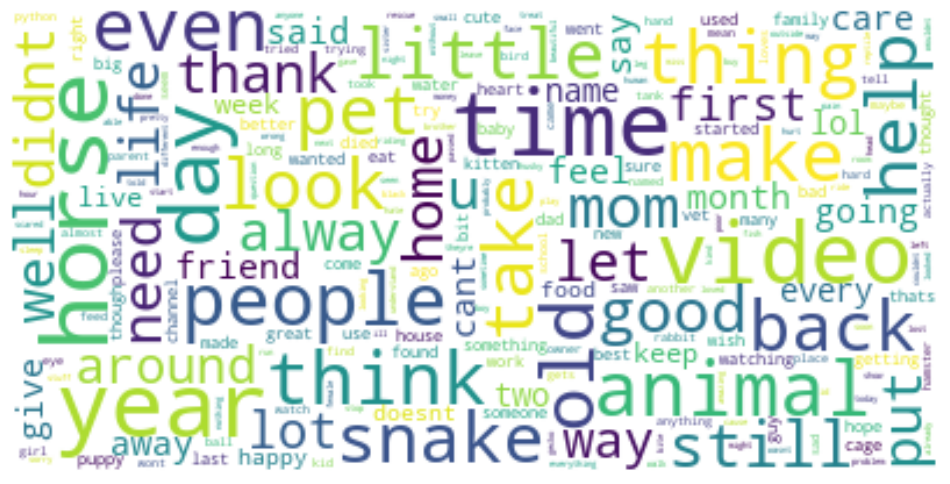

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join([(k + " ")*v for k,v in wc.items()])

wcloud = WordCloud(background_color="white", max_words=20000, collocations = False,
               contour_width=3, contour_color='steelblue',max_font_size=40)

# Generate a word cloud image
wcloud.generate(text)

# Display the generated image:
# the matplotlib way:
fig,ax0=plt.subplots(nrows=1,figsize=(12,8))
ax0.imshow(wcloud,interpolation='bilinear')

ax0.axis("off")
plt.show()

#### Topic modeling with LDA (beyond word frequency)
Raw word frequency / a word cloud isn't very informative (as noted in the original).
**LDA** instead learns latent topics -- groups of words that co-occur -- which reads much
more like real audience interests (training, food, health, rescue, ...). We run it on the
owners' stopword-filtered tokens and print the top words per topic.

In [41]:
from pyspark.ml.feature import CountVectorizer
from pyspark.ml.clustering import LDA

# Bag-of-words over the owners' filtered tokens (minDF drops ultra-rare words)
cv_topic = CountVectorizer(inputCol="filtered", outputCol="tf_topic",
                           vocabSize=5000, minDF=5.0).fit(df_all_owner)
df_topic = cv_topic.transform(df_all_owner)

lda = LDA(k=6, maxIter=20, featuresCol="tf_topic", seed=42)
lda_model = lda.fit(df_topic)

vocab = cv_topic.vocabulary
print("=== LDA topics among cat/dog owners (top 8 words each) ===")
for row in lda_model.describeTopics(8).collect():
    words = [vocab[i] for i in row['termIndices']]
    print("Topic %d:" % row['topic'], ", ".join(words))

=== LDA topics among cat/dog owners (top 8 words each) ===
Topic 0: birthday, heart, god, thats, show, kitten, bless, day
Topic 1: horse, horses, people, ride, riding, even, think, back
Topic 2: let, time, boat, german, turtle, puppy, lol, around
Topic 3: ears, tail, doberman, rottweiler, looks, white, 0, breed
Topic 4: name, little, food, died, day, two, looks, away
Topic 5: animals, time, old, people, take, always, years, life


#### 4. Identify Creators With Cat And Dog Owners In The Audience
* Simply filter out all dog and cat owners and aggregate the creators.


In [42]:
#Get all creators whenever the users label is True(cat/dog owner)
df_create = df_pets.select('creator_name').union(pred_all.filter(F.col('prediction') == 1.0).select('creator_name'))

df_create.createOrReplaceTempView("create_table")

#get count
create_count = spark.sql("select distinct creator_name, count(*) as Number\
                          from create_table \
                          group by creator_name \
                          order by Number DESC")

In [43]:
create_count.show()

+--------------------+------+
|        creator_name|Number|
+--------------------+------+
|    Brave Wilderness|  5051|
|       Brian Barczyk|  4197|
|            The Dodo|  3411|
|  Taylor Nicole Dean|  3372|
|Hope For Paws - O...|  1477|
|           Vet Ranch|  1410|
|  Think Like A Horse|  1380|
|       RaleighLink14|  1349|
|     Gohan The Husky|  1308|
|    Cole & Marmalade|  1189|
|        Robin Seplut|  1076|
|Zak Georges Dog T...|  1036|
|          stacyvlogs|  1023|
|Gone to the Snow ...|   965|
|     Viktor Larkhill|   875|
|            HammyLux|   619|
|            ViralHog|   533|
|   Talking Kitty Cat|   530|
|         Happy Tails|   530|
|             Steff J|   473|
+--------------------+------+
only showing top 20 rows


#### 5. Analysis and Future work   
1. Due to my limited comminity edition computational power, I toke partial of the dataset and downsampling a bit, but definitely want to increat to the whose dataset and run the test, to see the output.   
2. For seeing topic related to onwers, I don't have better ideas than checking out word frequency. We might harness some unsupervised learning techniques here, which I am not that familiar with, need to discuss with Mike.   
3. Tune parameters and do cross-validation. (I skip this part in my word since it's time consuming)